In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
library(readr)

dir.create("../../outputs/Extended/Ext-Frag-Boxplots-Histology", recursive = TRUE, showWarnings = FALSE)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching package: ‘pRO

In [2]:
mica_df <- read_csv("../../data/mica_df_with_pcs.csv")
lucas_df <- read_csv("../../data/lucas_df_w_pc_gemini2.csv")
val_df <- read_csv("../../data/val_df_with_pcs.csv")

mica_df <- mica_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

mica_df_filtered <- mica_df[mica_df$`Coded Type` %in% c("Lung (LU)", "No cancer (NC)"), ]

Rows: 540 Columns: 1304
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (73): id, Stage, Coded Type, type, Delfi ID (Aliquot 2), DL ID, DL Suf...
dbl (1225): clinical_CCI, clinical_age, Smoking, ratio_1, ratio_2, ratio_3, ...
lgl    (6): Match?, Rack (plasma), Rack (cfDNA), check, Robot Protocol, Repl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 287 Columns: 959
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (851): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_V

In [3]:
batch <- read_csv("../../data/LUCAS_batching.csv")

Rows: 419 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): id
dbl (1): library_batch

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
lucas_df <- inner_join(lucas_df, batch, by="id")

In [5]:
model_seq <- readRDS("../../data/mathios_architecture_seq.rds")

## Histology boxplots

In [6]:
df <- lucas_df
chosen_hist <- c("No baseline cancer", "Benign", "SCLC", "Adenocarcinoma", "Squamous")
#chosen_hist <- c("No baseline cancer", "Benign", "Adenocarcinoma", "Squamous")

df_hist <- df %>% dplyr::filter(clinical_histology %in% chosen_hist)


Attaching package: ‘colorspace’


The following object is masked from ‘package:pROC’:

    coords


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


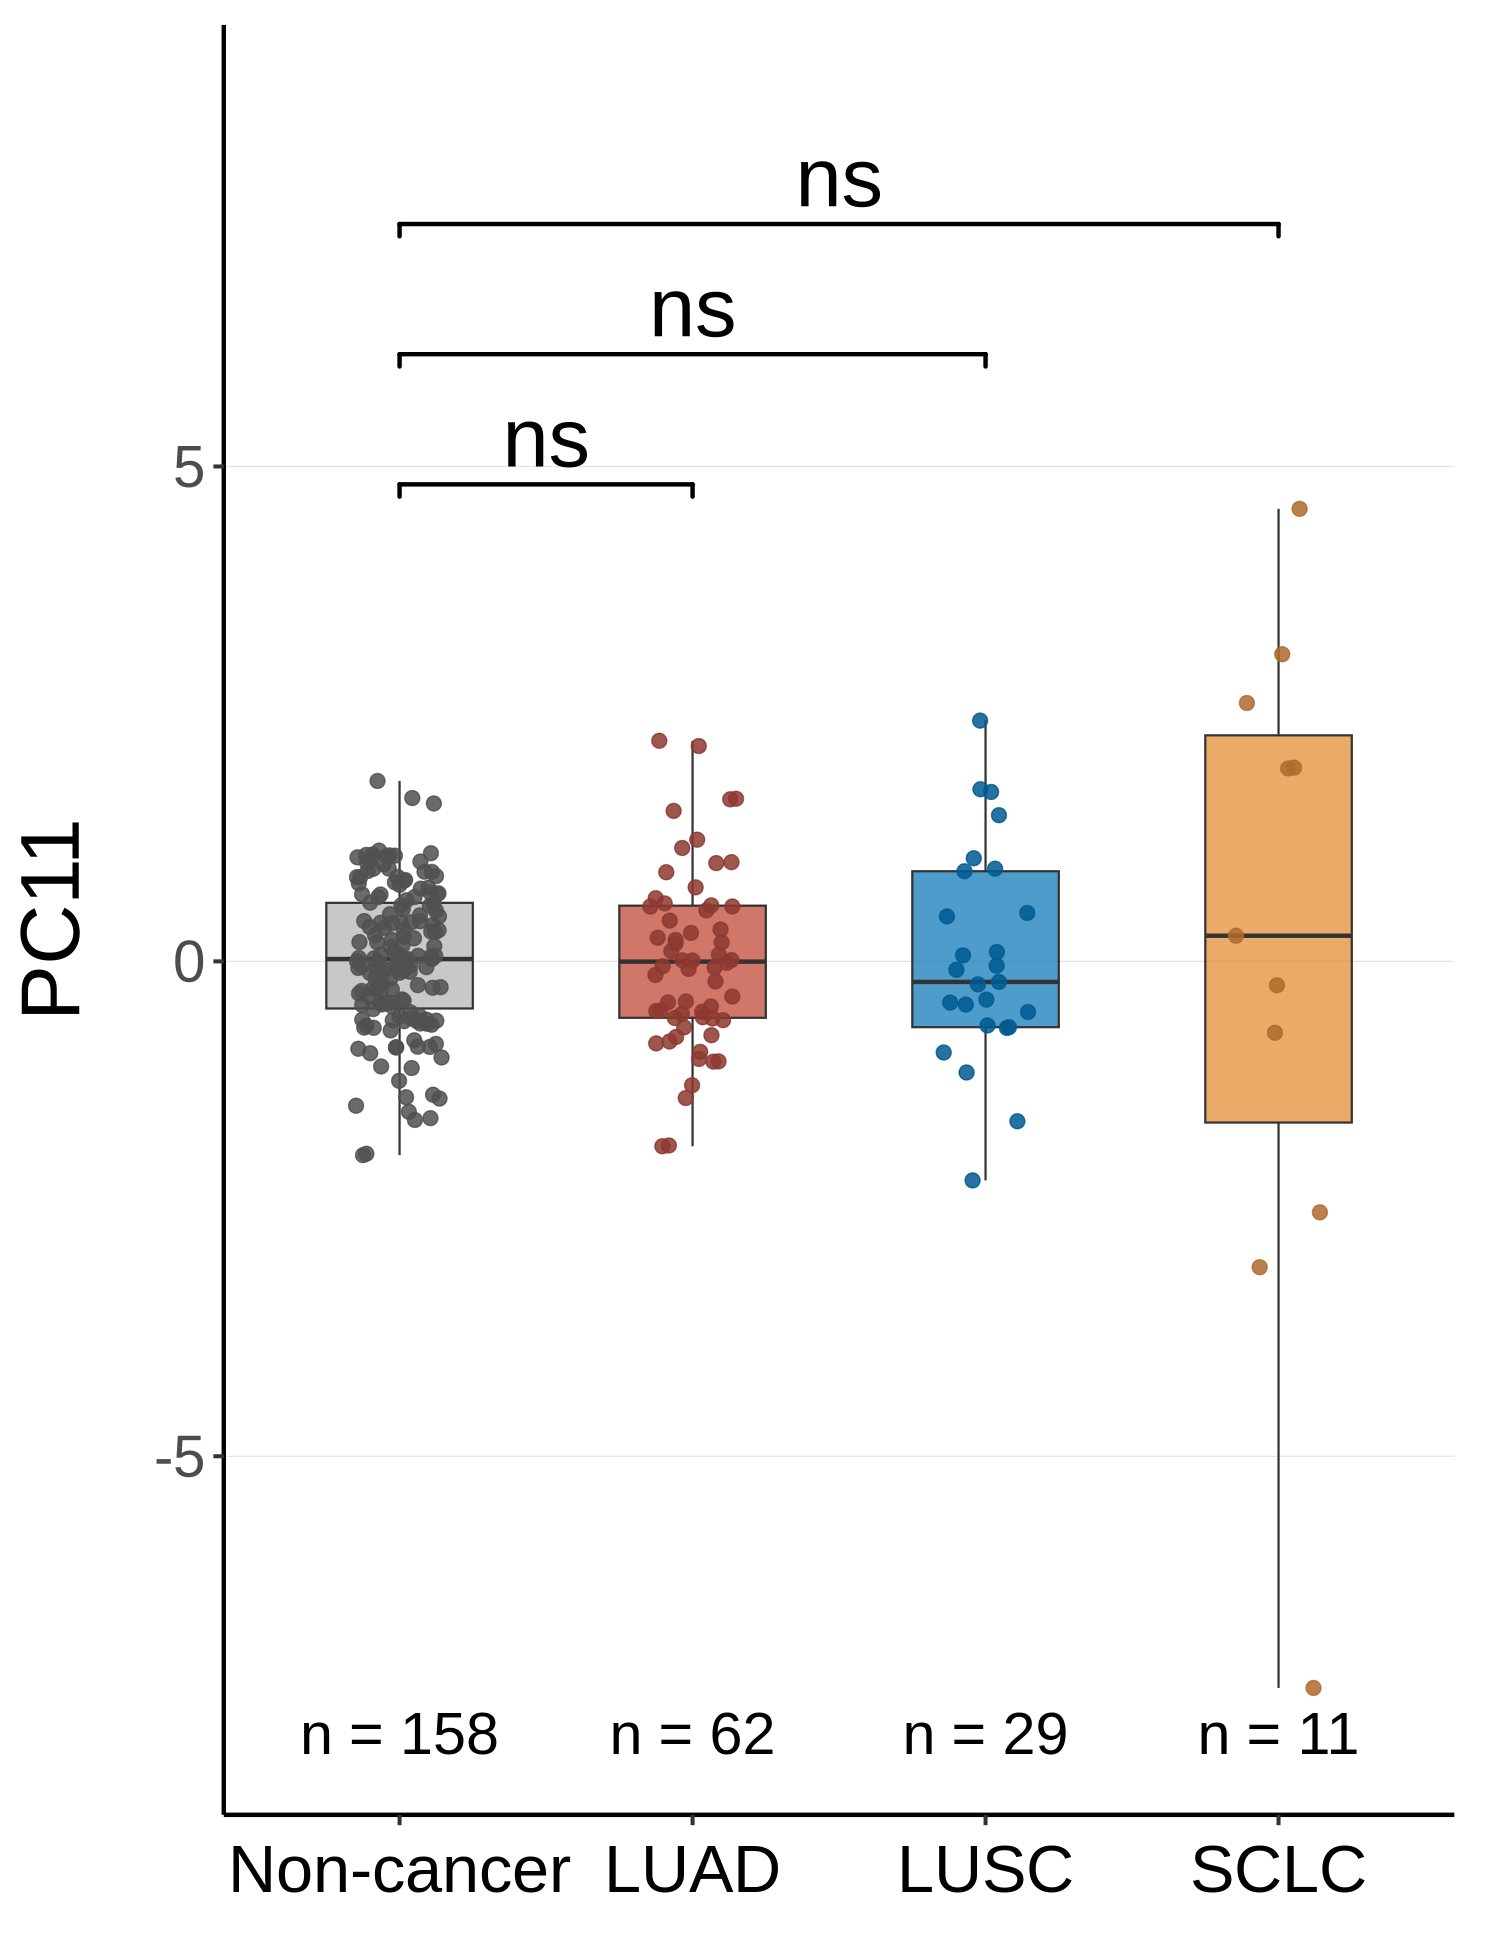

In [7]:
library(tidyverse)
library(ggpubr)
library(ggsci)
library(colorspace)

plot_biomarker_histology <- function(df,
                                     biomarker_col  = "ratio_pc_06",
                                     biomarker_name = "PC6 (ratio_pc_06)",
                                     histology_col  = "clinical_histology",
                                     ref_groups     = c("No baseline cancer", "Benign"),
                                     test_method    = c("t.test", "wilcox.test"),
                                     y_limits       = NULL,
                                     plot_title     = NULL,
                                     hide_outliers  = TRUE,
                                     show_y_axis    = TRUE) {

  test_method <- match.arg(test_method)

  # ---- Factor levels ----
  histology_levels <- c("No baseline cancer", "Benign", "Adenocarcinoma", "Squamous", "SCLC")

  # ---- Color palette ----
  nejm_cols <- ggsci::pal_nejm()(3)
  names(nejm_cols) <- c("Adenocarcinoma", "Squamous", "SCLC")

  fill_pal <- c(
    "Reference"      = "#B0B0B0",
    "Adenocarcinoma" = nejm_cols[["Adenocarcinoma"]],
    "Squamous"       = nejm_cols[["Squamous"]],
    "SCLC"           = nejm_cols[["SCLC"]]
  )

  point_pal <- c(
    "Reference"      = "#505050",
    "Adenocarcinoma" = colorspace::darken(nejm_cols[["Adenocarcinoma"]], 0.2),
    "Squamous"       = colorspace::darken(nejm_cols[["Squamous"]], 0.2),
    "SCLC"           = colorspace::darken(nejm_cols[["SCLC"]], 0.2)
  )

  # ---- Stage data (before biomarker filter, for n labels) ----
  df_hist <- df %>%
    filter(!is.na(.data[[histology_col]])) %>%
    mutate(!!histology_col := factor(.data[[histology_col]], levels = histology_levels)) %>%
    filter(!is.na(.data[[histology_col]]))

  if (nrow(df_hist) == 0) stop("No valid rows after histology grouping.")

  # ---- n labels: ALL samples per group (including biomarker NAs) ----
  sample_sizes <- df_hist %>%
    count(.data[[histology_col]], name = "n") %>%
    rename(Histology = 1) %>%
    arrange(Histology)

  # ---- Plotting dataframe: non-NA biomarker rows ----
  df_plot <- df_hist %>% filter(!is.na(.data[[biomarker_col]]))
  if (nrow(df_plot) == 0) stop("No valid rows after biomarker NA filtering.")

  # ---- Flag outliers ----
  if (hide_outliers) {
    df_plot <- df_plot %>%
      group_by(.data[[histology_col]]) %>%
      mutate(
        Q1      = quantile(.data[[biomarker_col]], 0.25, na.rm = TRUE),
        Q3      = quantile(.data[[biomarker_col]], 0.75, na.rm = TRUE),
        IQR_val = Q3 - Q1,
        is_outlier = .data[[biomarker_col]] < (Q1 - 1.5 * IQR_val) |
                     .data[[biomarker_col]] > (Q3 + 1.5 * IQR_val)
      ) %>%
      dplyr::select(-Q1, -Q3, -IQR_val) %>%
      ungroup()
  } else {
    df_plot$is_outlier <- FALSE
  }

  # ---- y-limits based on non-outlier values ----
  plot_values <- if (hide_outliers) {
    df_plot %>% filter(!is_outlier) %>% pull(.data[[biomarker_col]])
  } else {
    df_plot[[biomarker_col]]
  }
  plot_values <- plot_values[is.finite(plot_values)]

  y_min_local <- min(plot_values, na.rm = TRUE)
  y_max_local <- max(plot_values, na.rm = TRUE)
  y_rng_local <- y_max_local - y_min_local
  if (!is.finite(y_rng_local) || y_rng_local <= 0) y_rng_local <- 1

  if (is.null(y_limits)) {
    y_limits <- c(
      y_min_local - 0.08 * y_rng_local,
      y_max_local + 0.30 * y_rng_local
    )
  }

  y_range_for_positioning <- diff(y_limits)
  n_y <- y_limits[1] + 0.03 * y_range_for_positioning

  # ---- Merge reference groups into one level ----
  test_groups <- setdiff(levels(df_plot[[histology_col]]), ref_groups)
  test_groups <- test_groups[test_groups %in% unique(df_plot[[histology_col]])]

  df_plot_merged <- df_plot %>%
    mutate(
      HistologyMerged = if_else(
        .data[[histology_col]] %in% ref_groups,
        "Reference",
        as.character(.data[[histology_col]])
      ),
      HistologyMerged = factor(
        HistologyMerged,
        levels = c("Reference", setdiff(histology_levels, ref_groups))
      )
    )

  comparisons_merged <- lapply(test_groups, function(g) c("Reference", g))

  # ---- Bracket y positions ----
  top  <- y_limits[2]
  step <- 0.08 * y_range_for_positioning
  label_y <- rev(top - seq(from = step, by = step, length.out = length(test_groups)))

  # ---- Base plot ----
  p <- ggplot(df_plot_merged,
              aes(x = HistologyMerged,
                  y = .data[[biomarker_col]],
                  fill = HistologyMerged)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA, width = 0.5) +
    geom_jitter(
      data  = df_plot_merged %>% filter(!is_outlier),
      aes(color = HistologyMerged),
      width = 0.15, size = 3, alpha = 0.85
    ) +
    scale_fill_manual(values = fill_pal, guide = "none") +
    scale_color_manual(values = point_pal, guide = "none") +
    scale_x_discrete(labels = c(
      "Reference"      = "Non-cancer",
      "Adenocarcinoma" = "LUAD",
      "Squamous"       = "LUSC",
      "SCLC"           = "SCLC"
    )) +
    labs(
      x     = NULL,
      y     = if (show_y_axis) biomarker_name else NULL,
      title = plot_title
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0.02, 0.08)),
      breaks = scales::pretty_breaks(n = 6)
    ) +
    coord_cartesian(ylim = y_limits, clip = "off") +
    theme_classic(base_size = 20) +
    theme(
      axis.title.y       = element_text(size = 40, margin = margin(r = 20)),
      axis.text.x        = element_text(size = 32, color = "black", margin = margin(t = 10)),
      axis.text.y        = if (show_y_axis) element_text(size = 28) else element_blank(),
      axis.ticks.y       = if (show_y_axis) element_line() else element_blank(),
      axis.line.y        = if (show_y_axis) element_line(color = "black", linewidth = 1) else element_blank(),
      panel.grid.major.y = element_line(color = "grey90", size = 0.3),
      panel.grid.minor   = element_blank(),
      axis.line          = element_line(color = "black", linewidth = 1),
      legend.position    = "none",
      plot.margin        = margin(12, 22, 20, 10),
      plot.title         = element_text(size = 36, hjust = 0.5)
    )

  # ---- Stat brackets ----
  p <- p + stat_compare_means(
    comparisons  = comparisons_merged,
    method       = test_method,
    label        = "p.signif",
    label.y      = label_y,
    size         = 14,
    tip.length   = 0.01,
    bracket.size = 1.0
  )

  # ---- n = labels at bottom ----
  ref_n    <- sample_sizes %>% filter(Histology %in% ref_groups) %>% summarise(n = sum(n)) %>% pull(n)
  cancer_n <- sample_sizes %>% filter(!(Histology %in% ref_groups)) %>% arrange(Histology)

  merged_levels <- levels(df_plot_merged$HistologyMerged)
  n_labels <- c(ref_n, cancer_n$n)

  for (i in seq_along(merged_levels)) {
    p <- p + annotate(
      "text",
      x     = i,
      y     = n_y,
      label = paste0("n = ", n_labels[i]),
      size  = 10,
      color = "black"
    )
  }

  p
}

# ---- Example call ----
options(repr.plot.width = 10, repr.plot.height = 13, repr.plot.res = 150)

p <- plot_biomarker_histology(
  df             = df_hist,
  biomarker_col  = "ratio_pc_11",
  biomarker_name = "PC11",
  histology_col  = "clinical_histology",
  ref_groups     = c("No baseline cancer", "Benign"),
  test_method    = "wilcox.test",
  hide_outliers  = TRUE
)
p

In [8]:
save_all_ratio_pc_plots_histology <- function(
  df,
  pc_range       = 1:11,
  output_dir     = "../../outputs/Extended/Ext-Frag-Boxplots-Histology",
  histology_col  = "clinical_histology",
  ref_groups     = c("No baseline cancer", "Benign"),
  test_method    = "wilcox.test",
  hide_outliers  = TRUE,
  invert_pcs     = c(1, 2),   # PCs whose sign is flipped for display
  width          = 11,
  height         = 13,
  dpi            = 600
) {
  # Create output directory if it doesn't exist
  if (!dir.exists(output_dir)) {
    dir.create(output_dir, recursive = TRUE)
  }

  for (pc_num in pc_range) {
    biomarker_col  <- sprintf("ratio_pc_%02d", pc_num)
    biomarker_name <- sprintf("Fragmentome PC%d", pc_num)
    filename       <- file.path(output_dir, sprintf("Frag-PC%02d-Histology-Boxplot.png", pc_num))

    # Check column exists
    if (!(biomarker_col %in% names(df))) {
      message(sprintf("Skipping PC%d: column '%s' not found", pc_num, biomarker_col))
      next
    }

    # PCA component signs are arbitrary; flip the requested PCs for display only.
    # Statistical tests are two-sided, so p-values are unchanged.
    df_plot <- df
    if (pc_num %in% invert_pcs) {
      df_plot[[biomarker_col]] <- -df_plot[[biomarker_col]]
      message(sprintf("Inverting sign of %s for display", biomarker_col))
    }

    message(sprintf("Creating plot for %s...", biomarker_col))

    p <- plot_biomarker_histology(
      df             = df_plot,
      biomarker_col  = biomarker_col,
      biomarker_name = biomarker_name,
      histology_col  = histology_col,
      ref_groups     = ref_groups,
      test_method    = test_method,
      hide_outliers  = hide_outliers,
      show_y_axis    = TRUE
    )

    ggsave(
      filename = filename,
      plot     = p,
      width    = width,
      height   = height,
      dpi      = dpi,
      units    = "in"
    )
    message(sprintf("Saved: %s", filename))
  }
  message("Done! All histology plots saved.")
}

# Usage:
save_all_ratio_pc_plots_histology(
  df         = df_hist,
  pc_range   = 1:11,
  output_dir = "../../outputs/Extended/Ext-Frag-Boxplots-Histology",
  invert_pcs = c(1, 2)
)

Inverting sign of ratio_pc_01 for display

Creating plot for ratio_pc_01...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC01-Histology-Boxplot.png

Inverting sign of ratio_pc_02 for display

Creating plot for ratio_pc_02...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC02-Histology-Boxplot.png

Creating plot for ratio_pc_03...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC03-Histology-Boxplot.png

Creating plot for ratio_pc_04...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC04-Histology-Boxplot.png

Creating plot for ratio_pc_05...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC05-Histology-Boxplot.png

Creating plot for ratio_pc_06...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC06-Histology-Boxplot.png

Creating plot for ratio_pc_07...

Saved: ../../outputs/Extended/Ext-Frag-Boxplots-Histology/Frag-PC07-Histology-Boxplot.png

Creating plot for ratio_pc_08...

Saved

In [ ]:
## Done ##